In [2]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install feature_engine

Note: you may need to restart the kernel to use updated packages.


In [8]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from feature_engine.transformation import LogTransformer
from feature_engine.encoding import OneHotEncoder
from feature_engine.encoding import CountFrequencyEncoder
import category_encoders as ce
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats
from xgboost import XGBClassifier
from sklearn.utils import resample
import xgboost as xg
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,roc_auc_score
from imblearn.over_sampling import SMOTE
plt.style.use('ggplot')
pd.set_option('display.max.columns',500)

Explonatory Data Analysis: missing values, wrong data type checks , remove duplicates , correct invalid data set.

In [9]:
#data understanding
data = pd.read_csv("/kaggle/input/datasets/oluwanifemiabimbola/frauddetectiondataset/fraudTrain.csv")
data.head(2)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0


In [10]:
#random 10 rows of the data to avoid bias
data.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
223608,223608,2019-04-22 21:33:20,3523843138706408,"fraud_Monahan, Bogisich and Ledner",misc_pos,4.40,Grace,Williams,F,28812 Charles Mill Apt. 628,Plantersville,AL,36758,32.6176,-86.9475,1412,Drilling engineer,1970-11-20,6b48df21c8658d360e037522086b6093,1335130400,33.207903,-87.210016,0
198392,198392,2019-04-12 15:44:14,4476840372112,"fraud_Crist, Jakubowski and Littel",home,72.09,Steven,Walters,M,3206 Hall Divide Suite 282,Woodville,AL,35776,34.6689,-86.2296,3395,"Editor, commissioning",1979-01-21,dcaba4b0877fcc74af7e60bf474035e0,1334245454,34.225181,-85.435026,0
913796,913796,2019-12-29 17:33:21,630425673344,fraud_Ruecker-Mayert,kids_pets,91.25,Bryan,Miller,M,411 Laurie Fords,Cass,WV,24927,38.3880,-79.9906,365,Special effects artist,1970-03-14,034cf356062b9c9e3e0fc5a17ecc1c86,1356802401,38.157222,-79.111309,0
431896,431896,2019-07-12 21:17:02,341546199006537,fraud_Thiel-Thiel,entertainment,67.21,Mark,Brown,M,8580 Moore Cove,Wales,AK,99783,64.7556,-165.6723,145,"Administrator, education",1939-11-09,fb88364315121348e5da542bfcc4a8ae,1342127822,64.407069,-165.592094,0
830340,830340,2019-12-10 20:50:46,4755696071492,fraud_Quitzon-Goyette,home,35.88,Robert,Evans,M,01892 Patricia Vista Apt. 828,Sachse,TX,75048,32.9643,-96.6012,20328,Site engineer,1985-06-20,0e01c61bd0bea841ac71ae5773d1ba9f,1355172646,33.902036,-97.247230,0
278378,278378,2019-05-18 01:18:03,4561546772499,fraud_Ruecker Group,misc_net,7.89,Daniel,Briggs,M,7118 Jessica Unions Apt. 789,Moriarty,NM,87035,34.9889,-106.0609,7268,"Therapist, art",1988-08-04,55dba4379f75c5256066b652d1422d2b,1337303883,34.017173,-105.829492,0
1138623,1138623,2020-04-19 18:17:54,4642894980163,fraud_Dietrich-Fadel,health_fitness,4.68,Eddie,Mendez,M,1831 Faith View Suite 653,Clarinda,IA,51632,40.7491,-95.0380,7297,IT trainer,1990-07-13,617a8e617fc526944f70f42089932d95,1366395474,40.850480,-95.111875,0
173454,173454,2019-04-01 01:10:30,180046617132290,fraud_Ledner-Pfannerstill,gas_transport,72.01,Erika,Mason,F,083 Karen Island Apt. 656,Goreville,IL,62939,37.5750,-88.9655,3119,"Teacher, secondary school",1942-04-17,ec6b062747295b6d67b4693ad69bc913,1333242630,38.209217,-88.965960,0
1085500,1085500,2020-03-27 07:21:40,4642894980163,"fraud_Moen, Reinger and Murphy",grocery_pos,46.29,Eddie,Mendez,M,1831 Faith View Suite 653,Clarinda,IA,51632,40.7491,-95.0380,7297,IT trainer,1990-07-13,7d9d349c107385253d259c89be962983,1364368900,40.226154,-95.207158,0
506830,506830,2019-08-08 03:54:24,376445266762684,fraud_Cummings LLC,gas_transport,38.34,Rachel,Lowe,F,372 Jeffrey Course,Sutherland,NE,69165,41.1558,-101.1360,1789,Insurance broker,1982-02-11,e19007bd16946a189a9bffb82caf7b09,1344398064,41.440906,-101.858103,0


In [11]:
#checking the missing values and duplicate to avoid high bias in the model
missing_value = data.isna().sum()
duplicate_value = data.duplicated().sum()
print(f'Missing values:{missing_value}')
print(f'Duplicate Value:{duplicate_value}')

Missing values:Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
Duplicate Value:0


In [12]:
#checking the columns,shape rows and column types and describe
data.shape

(1296675, 23)

In [13]:
#the data columns
data.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [14]:
#make sure the features are in the right format
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [15]:
#more information on the data set
data.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


Feature engineering focusing on renaming , removing and creating new features
removing the cc_num as it has scale with large standard deviation as it is on different scale , same with the ID.
feature scaling for the zip, amt and city pop because of high scale value.
create distance features with lat and long,as it reduce dimentionality for simplicity sake for the model

In [16]:
#rename column
data = data.rename(columns={'Unnamed: 0':'ID'})

In [17]:
#confirm the column
data.columns

Index(['ID', 'trans_date_trans_time', 'cc_num', 'merchant', 'category', 'amt',
       'first', 'last', 'gender', 'street', 'city', 'state', 'zip', 'lat',
       'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time', 'merch_lat',
       'merch_long', 'is_fraud'],
      dtype='object')

In [18]:
#calculating the euclidean distance from a refrence point
ref_lat = data['lat'].mean()
ref_long = data['long'].mean()

data['distance_from_center'] = np.sqrt((data['lat'] - ref_lat) ** 2 + (data['long'] - ref_long)**2)

In [19]:
#drop the exsting lat and long column, drop last and first name
data = data.drop(['last','first'],axis=1)

In [20]:
#randoming checking the datset
data.sample(4)

,ID,trans_date_trans_time,cc_num,merchant,category,amt,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,distance_from_center
1091700,1091700,2020-03-30 02:20:36,213113028819344,fraud_Kiehn Inc,grocery_pos,64.71,F,77944 Daniels Valley Suite 921,Camden,NY,13316,43.3392,-75.7543,6460,Building control surveyor,1959-09-27,c87dfca9fb0432f9243401c9678f5d3f,1364610036,42.739256,-76.439222,0,15.247786
1034753,1034753,2020-03-04 17:10:32,4383521454815,"fraud_Denesik, Powlowski and Pouros",home,40.43,M,209 Austin Stream Apt. 231,Indianapolis,IN,46290,39.9347,-86.1633,910148,Academic librarian,1987-09-22,5a362767f53350a5cbf5bdf93440b040,1362417032,40.422387,-85.493503,0,4.296520
1247338,1247338,2020-06-03 07:14:03,639030014711,"fraud_Casper, Hand and Zulauf",grocery_pos,99.06,M,696 Matthew Ford Suite 157,Olmsted,IL,62970,37.1935,-89.0933,639,Mechanical engineer,1982-08-01,3a92b1fe98f7f61f41a32e023848b745,1370243643,38.162763,-88.118521,0,1.757962
337091,337091,2019-06-09 00:42:58,6526955903501879,"fraud_Stroman, Hudson and Erdman",gas_transport,70.12,F,7351 Cindy Well Suite 099,Naples,FL,34120,26.3304,-81.5871,276002,Medical technical officer,1950-12-14,94a0a39ce038e41be5e3a72b56b9f508,1339202578,26.726991,-81.189695,0,14.955021


In [21]:
#checking the data is balanace or not and it is imbalance , we have less of fraud data
data.groupby('is_fraud')['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [22]:
#convert date to year,month,day and into hour, minute and second.
data['transac_date'] = pd.to_datetime(data['trans_date_trans_time'])
data['year'] = data['transac_date'].dt.year
data['month'] = data['transac_date'].dt.month
data['quarter'] = data['transac_date'].dt.quarter
data['dayoftheweek'] = data['transac_date'].dt.day_of_week
data['time'] = data['transac_date'].dt.time
data['hour']= data['transac_date'].dt.hour
data['minute'] = data['transac_date'].dt.minute
data['second'] = data['transac_date'].dt.second

In [23]:
#computing the time since last transaction per customer in seconds
data = data.sort_values('transac_date')
data['time_since_last_transaction'] = (data.groupby('ID')['transac_date']
                                       .diff()
                                       .dt.total_seconds()
                                       .fillna(0)
)

In [24]:
#flagging the rapid transaction potential fraud :
#transaction under 60 seconds apart from the customer are a strong fraud indicator
data['is_rapid_txn'] = (data['time_since_last_transaction']< 60).astype(int)

In [25]:
#extracting the birth year to calculate their age to the time of fraud
data['dob'] = pd.to_datetime(data['dob'])
data['birth_year'] = data['dob'].dt.year
#calculatetheclientage
data['age'] = data['year'] - data['birth_year']

In [26]:
#group the time of the day into broader category like morning ,afternoon,evening,night
def categorize_time_of_day(hour):
    if hour >= 6 and hour <=11:
      return 'Morning'
    elif hour >=12 and hour <= 17:
      return 'Afternoon'
    elif hour >=18 and hour <=23:
      return 'evening'
    else:
      return 'Night'



data['season_of_day'] =data['hour'].apply(categorize_time_of_day)

In [27]:
#group the day of the week into week day and weekends
def group_week_day(dayofw):
  wk_day = [1,2,3,4,5]
  week_end = [0,6]
  if dayofw in wk_day:
    return 'weekday'
  else:
    return 'weekend'


data['time_of_the_week'] = data['dayoftheweek'].apply(group_week_day)


In [28]:
#drop the transac transac column since it has been converted
data = data.drop(['trans_date_trans_time','transac_date'],axis=1)

In [29]:
#drop the date of birth
data = data.drop(['dob','time'],axis=1)

Explonatory Data Analysis(Univariate and Muiltivariate): Understanding the features and the relationship between the features.

Text(0, 0.5, 'Sum of the Age')

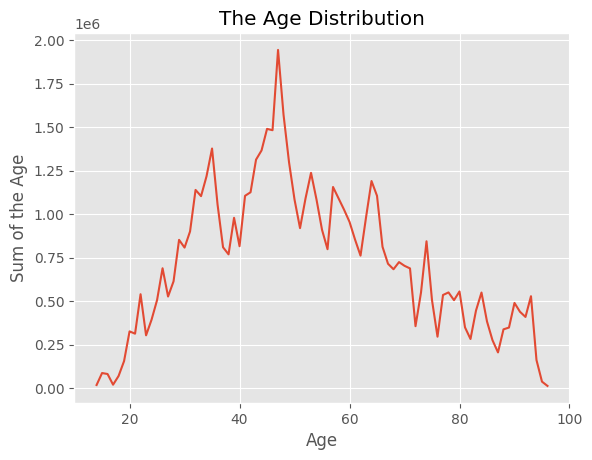

In [30]:
#age group distribution
age_grp = data.groupby('age')['age'].sum()
age_grp.plot(kind='line')
plt.title('The Age Distribution')
plt.xlabel('Age')
plt.ylabel('Sum of the Age')
#plt.xticks(rotation=90)


(array([-1.,  0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.]),
 [Text(-1.0, 0, '(evening, 1)'),
  Text(0.0, 0, '(Afternoon, 0)'),
  Text(1.0, 0, '(Afternoon, 1)'),
  Text(2.0, 0, '(Morning, 0)'),
  Text(3.0, 0, '(Morning, 1)'),
  Text(4.0, 0, '(Night, 0)'),
  Text(5.0, 0, '(Night, 1)'),
  Text(6.0, 0, '(evening, 0)'),
  Text(7.0, 0, '(evening, 1)'),
  Text(8.0, 0, '')])

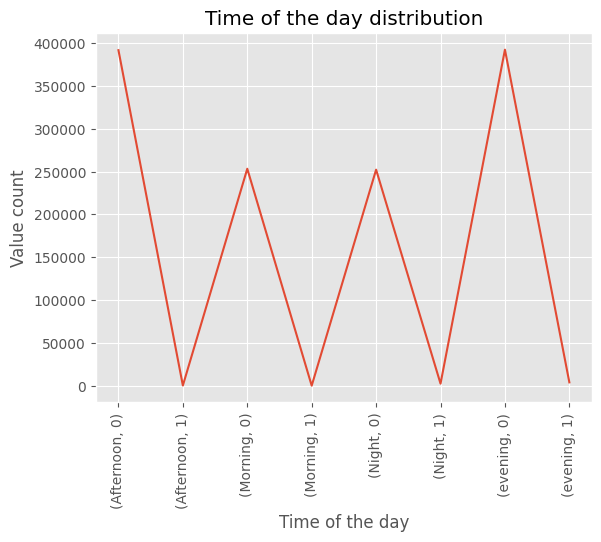

In [31]:
#time of day distribution
time_of_day = data.groupby('season_of_day')['is_fraud'].value_counts()
time_of_day.plot(kind='line')
plt.title('Time of the day distribution')
plt.xlabel('Time of the day')
plt.ylabel('Value count')
plt.xticks(rotation=90)

(array([-0.5,  0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5]),
 [Text(-0.5, 0, ''),
  Text(0.0, 0, '(weekday, 0)'),
  Text(0.5, 0, ''),
  Text(1.0, 0, '(weekday, 1)'),
  Text(1.5, 0, ''),
  Text(2.0, 0, '(weekend, 0)'),
  Text(2.5, 0, ''),
  Text(3.0, 0, '(weekend, 1)'),
  Text(3.5, 0, '')])

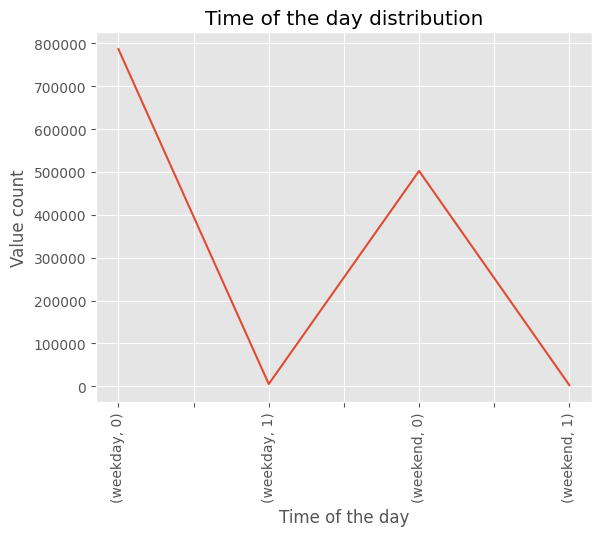

In [32]:
#Time of the day distribution
time_of_day = data.groupby('time_of_the_week')['is_fraud'].value_counts()
time_of_day.plot(kind='line')
plt.title('Time of the day distribution')
plt.xlabel('Time of the day')
plt.ylabel('Value count')
plt.xticks(rotation=90)

Text(0, 0.5, 'value count')

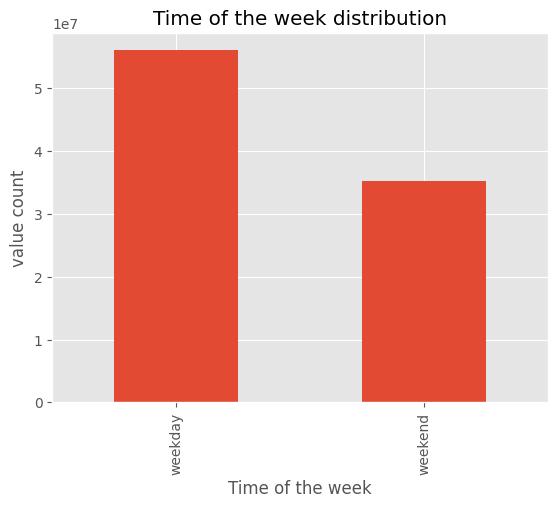

In [33]:
#Time of the day distribution
time_of_day = data.groupby('time_of_the_week')['amt'].sum()
time_of_day.plot(kind='bar')
plt.title('Time of the week distribution')
plt.xlabel('Time of the week')
plt.ylabel('value count')
#plt.xticks(rotation=90)

(array([-2.,  0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(-2.0, 0, 'shopping_pos'),
  Text(0.0, 0, 'entertainment'),
  Text(2.0, 0, 'gas_transport'),
  Text(4.0, 0, 'grocery_pos'),
  Text(6.0, 0, 'home'),
  Text(8.0, 0, 'misc_net'),
  Text(10.0, 0, 'personal_care'),
  Text(12.0, 0, 'shopping_pos'),
  Text(14.0, 0, '')])

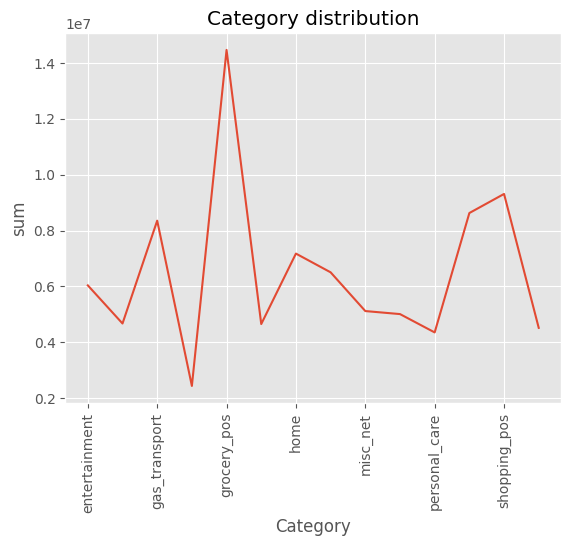

In [34]:
#category distribution
time_of_day = data.groupby('category')['amt'].sum()
time_of_day.plot(kind='line')
plt.title('Category distribution')
plt.xlabel('Category')
plt.ylabel('sum')
plt.xticks(rotation=90)

In [35]:
#merchant distribution in the dataset
data.groupby('merchant')['is_fraud'].value_counts().tail(10)

merchant                          is_fraud
fraud_Zemlak Group                0           1280
                                  1             17
fraud_Zemlak, Tillman and Cremin  0           1802
                                  1              2
fraud_Ziemann-Waters              0           1689
                                  1              6
fraud_Zieme, Bode and Dooley      0           2552
                                  1              8
fraud_Zulauf LLC                  0           1781
                                  1              2
Name: count, dtype: int64

In [36]:
#Category distribution in the dataset
data.groupby('category')['is_fraud'].value_counts()

category        is_fraud
entertainment   0            93781
                1              233
food_dining     0            91310
                1              151
gas_transport   0           131041
                1              618
grocery_net     0            45318
                1              134
grocery_pos     0           121895
                1             1743
health_fitness  0            85746
                1              133
home            0           122917
                1              198
kids_pets       0           112796
                1              239
misc_net        0            62372
                1              915
misc_pos        0            79405
                1              250
personal_care   0            90538
                1              220
shopping_net    0            95830
                1             1713
shopping_pos    0           115829
                1              843
travel          0            40391
                1             

In [37]:
# the distribution of age with fraud
data.groupby('age')['is_fraud'].value_counts().sample(10)

age  is_fraud
70   1              89
18   1              58
42   0           26704
19   1              42
65   0           16901
83   0            5353
51   1             109
61   1             113
37   1             115
84   0            6486
Name: count, dtype: int64

In [38]:
#gender distribution
data.groupby('gender')['is_fraud'].value_counts()

gender  is_fraud
F       0           706128
        1             3735
M       0           583041
        1             3771
Name: count, dtype: int64

<Axes: title={'center': 'the difference in the gender distribution'}, xlabel='gender'>

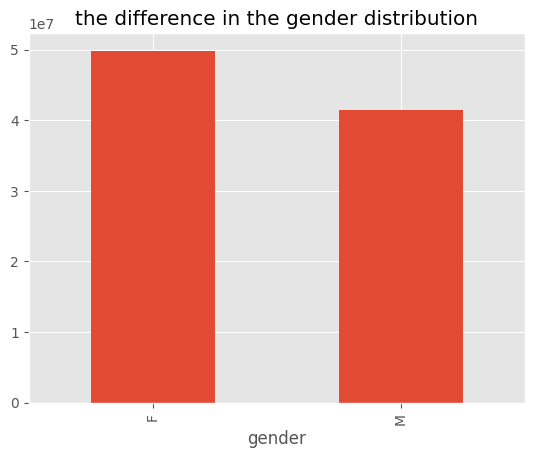

In [39]:
#plotting the distribution of data among the gender
gender_dist = data.groupby('gender')['amt'].sum()
gender_dist.plot(kind='bar',title='the difference in the gender distribution')

<Axes: xlabel='is_fraud'>

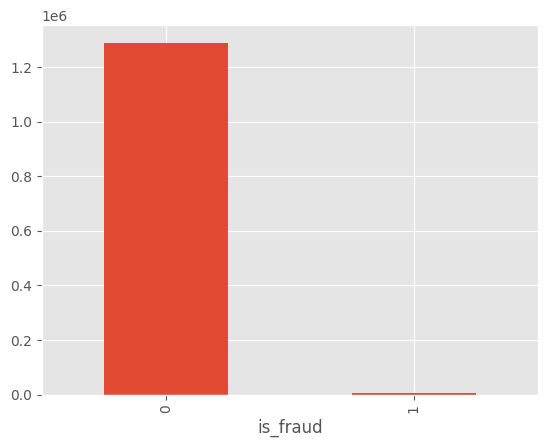

In [40]:
#the fraud dataset distribution
fraud_distribution = data.groupby('is_fraud')['is_fraud'].value_counts()
fraud_distribution.plot(kind='bar')

In [41]:
#correlation for the features relationship
#Extracting the numeric data
numerical_cos = data.select_dtypes(include=[np.number])
numerical_cos.corr()

,ID,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,distance_from_center,year,month,quarter,dayoftheweek,hour,minute,second,time_since_last_transaction,is_rapid_txn,birth_year,age
ID,1.000000,0.000386,-0.000251,0.000709,0.000602,-0.000676,-0.001678,0.998971,0.000541,-0.000671,-0.004767,-0.001126,0.783311,0.181956,0.151242,-0.030910,0.001073,0.000030,0.000174,NaN,NaN,0.003736,0.016644
cc_num,0.000386,1.000000,0.001769,0.041459,-0.059271,-0.048278,-0.008991,0.000354,-0.058942,-0.048252,-0.000981,0.053220,0.000466,-0.000281,-0.000465,-0.002481,-0.000801,0.000812,0.000036,NaN,NaN,0.000291,-0.000279
amt,-0.000251,0.001769,1.000000,0.001843,-0.001926,-0.000187,0.005818,-0.000293,-0.001873,-0.000151,0.219404,0.002640,0.000842,-0.001748,-0.001962,-0.001001,-0.022811,0.000383,0.001405,NaN,NaN,0.009748,-0.009724
zip,0.000709,0.041459,0.001843,1.000000,-0.114290,-0.909732,0.078467,0.000670,-0.113561,-0.908924,-0.002162,0.227925,0.000086,0.000852,0.000500,-0.001353,0.005938,0.000766,0.000127,NaN,NaN,-0.011004,0.011004
lat,0.000602,-0.059271,-0.001926,-0.114290,1.000000,-0.015533,-0.155730,0.000632,0.993592,-0.015509,0.001894,0.185967,0.001274,-0.001072,-0.001342,0.000498,-0.011508,-0.000243,-0.000221,NaN,NaN,-0.047845,0.047868
long,-0.000676,-0.048278,-0.000187,-0.909732,-0.015533,1.000000,-0.052715,-0.000642,-0.015452,0.999120,0.001721,-0.519266,0.000191,-0.001213,-0.000697,0.001593,-0.002290,-0.000825,0.000325,NaN,NaN,0.030231,-0.030220
city_pop,-0.001678,-0.008991,0.005818,0.078467,-0.155730,-0.052715,1.000000,-0.001714,-0.154781,-0.052687,0.002136,0.056586,-0.001673,0.000137,-0.000280,0.002439,0.020381,-0.000713,0.000690,NaN,NaN,0.091271,-0.091295
unix_time,0.998971,0.000354,-0.000293,0.000670,0.000632,-0.000642,-0.001714,1.000000,0.000561,-0.000635,-0.005078,-0.001145,0.782582,0.184868,0.153618,-0.029284,0.000756,0.000006,0.000191,NaN,NaN,0.003655,0.016707
merch_lat,0.000541,-0.058942,-0.001873,-0.113561,0.993592,-0.015452,-0.154781,0.000561,1.000000,-0.015431,0.001741,0.184745,0.001244,-0.001116,-0.001428,0.000263,-0.011378,-0.000217,-0.000281,NaN,NaN,-0.047458,0.047480
merch_long,-0.000671,-0.048252,-0.000151,-0.908924,-0.015509,0.999120,-0.052687,-0.000635,-0.015431,1.000000,0.001721,-0.518812,0.000184,-0.001197,-0.000688,0.001553,-0.002325,-0.000820,0.000310,NaN,NaN,0.030154,-0.030142


In [42]:
#checking the skewness of the numeric data
#ignoring the skew data , since its random forest model
numerical_cos.skew()

ID                            -5.176828e-15
cc_num                         2.851879e+00
amt                            4.227787e+01
zip                            7.968076e-02
lat                           -1.860277e-01
long                          -1.150108e+00
city_pop                       5.593853e+00
unix_time                      3.377950e-03
merch_lat                     -1.819154e-01
merch_long                    -1.146960e+00
is_fraud                       1.302912e+01
distance_from_center           2.245465e+00
year                           9.430622e-01
month                          2.985158e-01
quarter                        2.585613e-01
dayoftheweek                  -7.845304e-02
hour                          -2.828255e-01
minute                        -3.937129e-04
second                        -6.966114e-04
time_since_last_transaction    0.000000e+00
is_rapid_txn                   0.000000e+00
birth_year                    -6.123585e-01
age                            6

In [43]:
numerical_cos.columns

Index(['ID', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'distance_from_center', 'year',
       'month', 'quarter', 'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'birth_year', 'age'],
      dtype='object')

<Axes: ylabel='Frequency'>

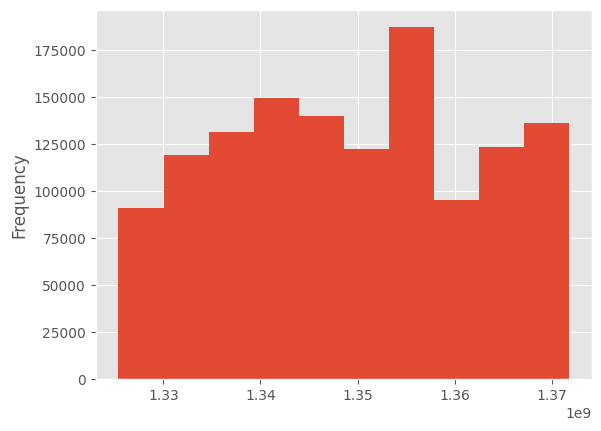

In [44]:
#positive skewed data evaluating via histogram cc_num,amt,zip,city_pop,age, unix, distance_from_center,year,month,quarter 
numerical_cos['unix_time'].plot(kind='hist')

In [45]:
#log transformation on skew data
skewed_data = ['amt','city_pop','distance_from_center']

# Apply natural log
data[skewed_data] = data[skewed_data].apply(np.log1p)

In [46]:
#remove ccnum and id
data = data.drop(columns=['cc_num','ID','birth_year','trans_num'], axis=1)

In [47]:
#the function to calculate the difference in the target value
def percentage_increase(fra,not_frad):
    percentage_difference_fra = round((fra/(fra + not_frad)) * 100, 2)
    percentage_difference_not_frad = round((not_frad/(fra + not_frad)) *100,2)
    return (f'fraud:{percentage_difference_fra}, Not Fraud:{percentage_difference_not_frad}')


fra = data['is_fraud'].value_counts()[1]
not_frad = data['is_fraud'].value_counts()[0]

percentage_increase(fra,not_frad)

'fraud:0.58, Not Fraud:99.42'

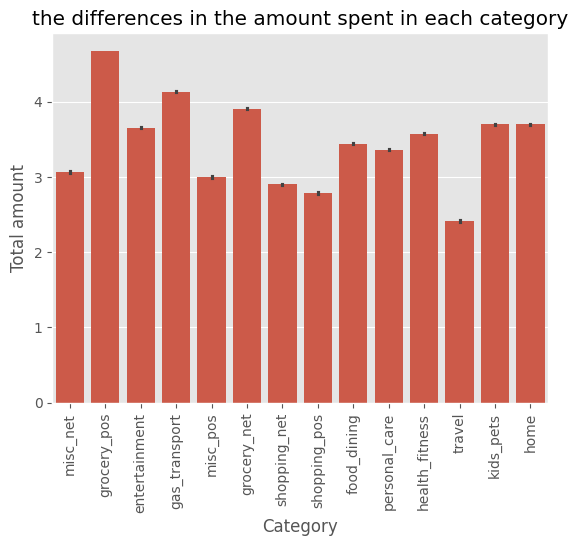

In [48]:
#category amount distribution
sns.barplot(data=data, x='category', y='amt')
plt.title('the differences in the amount spent in each category')
plt.xlabel('Category')
plt.ylabel('Total amount')
plt.xticks(rotation=90)
plt.show()

Splitting of the dataset into Train and Test set

In [49]:
#splitting data into input and output
X = data.drop(['is_fraud'], axis = 1)
y = data['is_fraud']

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=23)

Encoding the categorical data: For the test data we use the transform while the train data we use the fit. It is best to encode the dataset after split to avoid data leakeage.


In [51]:
#Extracting the numeric data
numerical_columns = X_train.select_dtypes(include=[np.number])
numerical_columns.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'month', 'quarter',
       'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age'],
      dtype='object')

In [52]:
#extracting the categorical data
categorical_columns = X_train.select_dtypes(include=['object'])
categorical_columns.columns

Index(['merchant', 'category', 'gender', 'street', 'city', 'state', 'job',
       'season_of_day', 'time_of_the_week'],
      dtype='object')

In [53]:
#for columns like month minute,hour,day of the week, second we need cyclical encoding,
 #but since it is random forest we will leave it' cyclical encoding does not have any significant
 #on tree models. but we keep it for other models
# Hour: 24-hour cycle
X_train['hour_sin'] = np.sin(2 * np.pi * X_train['hour'] / 24)
X_train['hour_cos'] = np.cos(2 * np.pi * X_train['hour'] / 24)

# #x_test
X_test['hour_sin'] = np.sin(2 * np.pi * X_test['hour'] / 24)
X_test['hour_cos'] = np.cos(2 * np.pi * X_test['hour'] / 24)

# Day of week: 7-day cycle
X_train['day_sin'] = np.sin(2 * np.pi * X_train['dayoftheweek'] / 7)
X_train['day_cos'] = np.cos(2 * np.pi * X_train['dayoftheweek'] / 7)

# #X_test
X_test['day_sin'] = np.sin(2 * np.pi * X_test['dayoftheweek'] / 7)
X_test['day_cos'] = np.cos(2 * np.pi * X_test['dayoftheweek'] / 7)


# Month: 12-month cycle
X_train['month_sin'] = np.sin(2 * np.pi * X_train['month'] / 12)
X_train['month_cos'] = np.cos(2 * np.pi * X_train['month'] / 12)

# #X_test
X_test['month_sin'] = np.sin(2 * np.pi * X_test['month'] / 12)
X_test['month_cos'] = np.cos(2 * np.pi * X_test['month'] / 12)

# Drop the original columns after encoding
X_train = X_train.drop(columns=['hour', 'dayoftheweek', 'month'])
X_test = X_test.drop(columns=['hour', 'dayoftheweek', 'month'])

In [54]:
numerical_columns.columns

Index(['amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'month', 'quarter',
       'dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age'],
      dtype='object')

(array([1, 2, 3, 4]),
 [Text(1, 0, 'amt'),
  Text(2, 0, 'lat'),
  Text(3, 0, 'long'),
  Text(4, 0, 'city_pop')])

<Figure size 4000x2400 with 0 Axes>

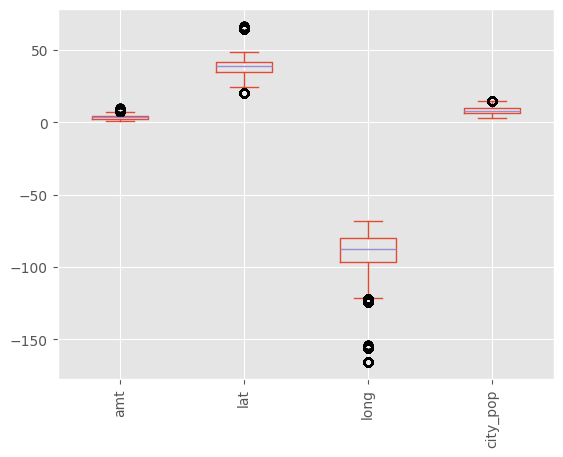

In [55]:
#for outliers
from matplotlib.pyplot import figure

figure(figsize=(50, 30), dpi=80)
sub_numeric =numerical_columns[['amt', 'lat', 'long', 'city_pop']]
sub_numeric_2 =numerical_columns[['dayoftheweek', 'hour', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age']]
sub_numeric.plot(kind='box')
plt.xticks(rotation=90)

In [56]:
#removing outlier

def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    outlier_summary = {}

    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df_clean[
        (df_clean[col] < lower) |
        (df_clean[col] > upper)
         ].shape[0]

        outlier_summary[col] = outliers

       # Remove outliers
        df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
        ]
 
    for col, count in outlier_summary.items():
        print(f" {col}: {count} outliers")

        print(f"\nOriginal shape: {df.shape}")
        print(f"Clean shape: {df_clean.shape}")

    return df_clean

# Your numerical columns
numerical_cols = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat',
       'merch_long', 'distance_from_center', 'year', 'quarter', 'minute', 'second',
       'time_since_last_transaction', 'is_rapid_txn', 'age']
X_train_clean = remove_outliers_iqr(X_train, numerical_cols)

 amt: 542 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 lat: 3176 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 long: 30252 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 city_pop: 2791 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 unix_time: 0 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 merch_lat: 161 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 merch_long: 7260 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 distance_from_center: 15004 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 year: 0 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 quarter: 0 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 minute: 0 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 second: 0 outliers

Original shape: (868772, 31)
Clean shape: (809236, 31)
 time_since_last_transaction: 0 outliers

Original

In [57]:
# #for columns like zip, merchant,job,transnum,category,street, city, state,frequency encoder:
# #frequency encoder works by replacing values base on the number or percentage of times they appear.
# #convert zip to categorical data
X_train['zip'] = X_train['zip'].astype(str)
X_test['zip'] = X_test['zip'].astype(str)

In [58]:
#part 2 of encoding the features using frequency encoder
#zip, merchant,job,transnum,category,street, city, state
encoder = CountFrequencyEncoder(encoding_method='frequency',
                                variables=['merchant','zip','job',
                                           'category','street','city','state'],
)

encoder.fit(X_train)

CountFrequencyEncoder(encoding_method='frequency',
                      variables=['merchant', 'zip', 'job', 'category', 'street',
                                 'city', 'state'])

In [59]:
#fit the transform on the training and test data
X_train = encoder.transform(X_train)
X_test = encoder.transform(X_test)

print(X_train.head())

         merchant  category       amt gender    street      city     state  \
959450   0.001712  0.087260  4.655768      F  0.000376  0.000376  0.072860   
318688   0.002006  0.101678  3.860098      M  0.001616  0.001616  0.064552   
551819   0.001907  0.090087  1.166271      M  0.000764  0.000764  0.024262   
1045421  0.001532  0.075235  1.000632      F  0.002354  0.002354  0.035783   
199338   0.000988  0.048795  0.959350      F  0.001592  0.001592  0.018573   

              zip      lat      long  city_pop       job   unix_time  \
959450   0.000376  31.9240 -105.2099  6.363028  0.000376  1358711966   
318688   0.001616  41.4575  -74.1659  7.722678  0.004699  1338634720   
551819   0.000764  43.8295  -93.8282  6.992096  0.002321  1345803265   
1045421  0.002354  42.9147  -83.4845  8.846785  0.002773  1362845970   
199338   0.001592  41.4972  -98.7858  6.234411  0.001998  1334279313   

         merch_lat  merch_long  distance_from_center  year  quarter  minute  \
959450   32.732288 

In [60]:
X_train.shape

(868772, 31)

In [61]:
#for columns like gender,  'time_of_the_week' binary encoder
#fit into the train set and transform on both train and test set
binary_encoder = ce.BinaryEncoder(cols=['gender','time_of_the_week'],
                                  return_df=True)
#fit the transform on the training and test data
binary_encoder.fit(X_train)
X_train = binary_encoder.transform(X_train)
X_test = binary_encoder.transform(X_test)

print(X_train.head())

         merchant  category       amt  gender_0  gender_1    street      city  \
959450   0.001712  0.087260  4.655768         0         1  0.000376  0.000376   
318688   0.002006  0.101678  3.860098         1         0  0.001616  0.001616   
551819   0.001907  0.090087  1.166271         1         0  0.000764  0.000764   
1045421  0.001532  0.075235  1.000632         0         1  0.002354  0.002354   
199338   0.000988  0.048795  0.959350         0         1  0.001592  0.001592   

            state       zip      lat      long  city_pop       job  \
959450   0.072860  0.000376  31.9240 -105.2099  6.363028  0.000376   
318688   0.064552  0.001616  41.4575  -74.1659  7.722678  0.004699   
551819   0.024262  0.000764  43.8295  -93.8282  6.992096  0.002321   
1045421  0.035783  0.002354  42.9147  -83.4845  8.846785  0.002773   
199338   0.018573  0.001592  41.4972  -98.7858  6.234411  0.001998   

          unix_time  merch_lat  merch_long  distance_from_center  year  \
959450   135871196

In [62]:
#checking the cardinality of the variable
X_train[['season_of_day']].nunique()

season_of_day    4
dtype: int64

In [63]:
# for the 'season_of_day', one hot encoding
one_hot_encoder = OneHotEncoder(
    variables=['season_of_day'],
    drop_last=True,
    )

one_hot_encoder.fit(X_train)

OneHotEncoder(drop_last=True, variables=['season_of_day'])

In [64]:
X_train = one_hot_encoder.transform(X_train)
X_test = one_hot_encoder.transform(X_test)

print(X_train.head())

         merchant  category       amt  gender_0  gender_1    street      city  \
959450   0.001712  0.087260  4.655768         0         1  0.000376  0.000376   
318688   0.002006  0.101678  3.860098         1         0  0.001616  0.001616   
551819   0.001907  0.090087  1.166271         1         0  0.000764  0.000764   
1045421  0.001532  0.075235  1.000632         0         1  0.002354  0.002354   
199338   0.000988  0.048795  0.959350         0         1  0.001592  0.001592   

            state       zip      lat      long  city_pop       job  \
959450   0.072860  0.000376  31.9240 -105.2099  6.363028  0.000376   
318688   0.064552  0.001616  41.4575  -74.1659  7.722678  0.004699   
551819   0.024262  0.000764  43.8295  -93.8282  6.992096  0.002321   
1045421  0.035783  0.002354  42.9147  -83.4845  8.846785  0.002773   
199338   0.018573  0.001592  41.4972  -98.7858  6.234411  0.001998   

          unix_time  merch_lat  merch_long  distance_from_center  year  \
959450   135871196

In [65]:
# #ignoring the skewness and outlier for random forest
# #Imbalance dataset
# smote = SMOTE(sampling_strategy='minority', random_state=42)
# X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values,
#         color=['skyblue','salmon'])
# plt.xticks([0,1], ['Non-Fraud', 'Fraud'])
# plt.ylabel("Count")
# plt.title("Class Distribution AFTER SMOTE")
# plt.show()

In [66]:
#calculate the scale_pos_weight
ratio = (y_train == 0).sum()/(y_train==1).sum()
print(ratio)

170.66014621616281


In [67]:
# #hyperparameter tuning using the gridsearch
 grid= {       'c' : [0.001, 20],
             'penalty' : ['elasticnet'],
             'solver' : ['lbfgs'],
              'tol' : [1e-4],
              'max_iter':[100,500],
                'class_weight':['balanced']
             }

In [68]:
# Create the RandomizedSearchCV object
estimators = LogisticRegressor()
gs=RandomizedSearchCV(estimator= estimators,
                      param_distributions=grid, 
                      n_iter = 20,
                      cv=5,
                      n_jobs = -1,
                      scoring = 'f1',
                      random_state = 42)
# now fit the dataset to the GridSearchCV object. 
#sampling of the data
X_sample, y_sample = resample(X_train_sm,y_train_sm,
                             n_samples = 50000,random_state = 42)
gs= gs.fit(X_sample, y_sample)

In [69]:
# 1. Fit the RandomizedSearchCV object
best_params = gs.best_params_
best_score = gs.best_score_
print(best_params)
print(best_score)

In [70]:
#feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
#fitting xgboost

model =LogisticRegression(random_state=0,
                          solver = 'lbfgs',
                          C= 0.01,
                          max_iter=1000,
                          class_weight='balanced')
model.fit(X_train,y_train)

y_pred_sm = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred_sm)*100, 2), "%\n")
print('ROC-AUC:',roc_auc_score(y_test,y_pred_sm))
print("Classification Report:\n", classification_report(y_test, y_pred_sm))

In [ ]:
# Compare train vs test performance for overfitting 
y_train_pred = model.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, y_train_pred))
print("Test accuracy:", accuracy_score(y_test, y_pred_sm))

In [ ]:
#confusion matrics graph
sns.heatmap(confusion_matrix(y_test, y_pred_sm), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix AFTER SMOTE")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
#improving the model precision by using shap to understand the feature ,
#hyperparameter tuning ,more feature engineering,threshold tuning,resampling
#using shap
# Fits the explainer
explainer = shap.LinearExplainer(model)
# Calculates the SHAP values - It takes some time
shap_values = explainer.shap_values(X_test)

In [ ]:
#plotiing the shap values
shap.plots.bar(shap_values)


In [ ]:
shap.plots.bar(shap_values[0])

In [ ]:
# shap.plots.beeswarm(shap_values)